# Exploratory Data Analysis — Amazon Beauty Product Recommendations
### Fairness & Diversity Perspective

This notebook performs a structured EDA on the Amazon Beauty product-ratings dataset, examining:
- Popularity bias in item exposure
- Rating distributions
- Product-type landscape and product-type-level exposure inequality
- User activity patterns
- The tension between item fairness and intra-list diversity

**Data file required** (place in the same directory as this notebook):
- `amazon_beauty.csv` — columns: `UserId, ProductId, Rating, ProductType`

This mirrors the structure used in our MovieLens / Last.fm / Book-Crossing EDA notebooks so that
findings are directly comparable across domains. Wherever MovieLens used *genres*, here we use
**ProductType** as the categorical axis over which a user's interests — and a recommender's
calibration — can be measured.


---
## 0 — Setup & Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import MultiLabelBinarizer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
np.random.seed(42)

print('Libraries loaded ✓')


Libraries loaded ✓


---
## 1 — Load Data


In [3]:
ratings = pd.read_csv('../dataset/amazon/Amazon_Beauty.csv')

# Standardise column names just in case the raw export differs slightly
ratings.columns = [c.strip() for c in ratings.columns]
ratings = ratings.rename(columns={
    'userId': 'UserId', 'productId': 'ProductId',
    'rating': 'Rating', 'productType': 'ProductType',
    'category': 'ProductType', 'Category': 'ProductType',
})
ratings = ratings[['UserId', 'ProductId', 'Rating', 'ProductType']].dropna(subset=['UserId', 'ProductId', 'Rating'])
ratings['Rating'] = ratings['Rating'].astype(float)

# Drop duplicate (user, product) interactions — keep the first occurrence
ratings = ratings.drop_duplicates(subset=['UserId', 'ProductId'], keep='first').reset_index(drop=True)

n_users   = ratings['UserId'].nunique()
n_items   = ratings['ProductId'].nunique()
n_ratings = len(ratings)
density   = n_ratings / (n_users * n_items) * 100

print(f'Ratings  : {n_ratings:,}')
print(f'Products : {n_items:,}')
print(f'Users    : {n_users:,}')
print(f'Density  : {density:.6f}%')
print()
print('--- ratings sample ---')
display(ratings.head(3))
print()
print('Unique product types:', ratings['ProductType'].nunique())
print(ratings['ProductType'].value_counts())


Ratings  : 1,348,246
Products : 23,838
Users    : 883,753
Density  : 0.006400%

--- ratings sample ---


,UserId,ProductId,Rating,ProductType
0,A3NHUQ33CFH3VM,B00LLPT4HI,5.0,Eyeliner & Kajal
1,A1TIRNQ7O4REOH,B00LLPT4HI,4.0,Eyeliner & Kajal
2,A2Y36BR4YSY9F7,B00LLPT4HI,5.0,Eyeliner & Kajal



Unique product types: 22
ProductType
Nail Polish              374551
Shower Gel               204902
Sunscreen                133427
Shampoo                  121436
Face Wash & Cleansers    112020
Hair Color & Heena        81871
Face Serum                54001
Conditioner               50432
Body Lotion               46837
Cream & Moisturizer       34109
Deo & Perfume             32093
Kits & Accessories        21087
Eye Shadow & Mascara      18083
Trimmers & Clippers       15570
Sheet Mask                11189
Body Scrubs                8435
Shaving Foam & Gels        8041
Lipstick                   7164
Bath Salts                 7031
Hair Oil                   2747
Talcum Powder              2526
Eyeliner & Kajal            694
Name: count, dtype: int64


---
## 2 — Item-Level Statistics (Exposure & Popularity)


In [4]:
item_stats = (
    ratings.groupby('ProductId')
    .agg(
        n_ratings   = ('Rating', 'count'),
        mean_rating = ('Rating', 'mean'),
        n_users     = ('UserId', 'nunique'),
        ProductType = ('ProductType', 'first'),
    )
    .reset_index()
)

# Popular = top 20% by number of ratings (exposure-based)
pop_threshold = item_stats['n_ratings'].quantile(0.80)
item_stats['is_popular'] = (item_stats['n_ratings'] >= pop_threshold).astype(int)

popular_rating_share = (
    item_stats.loc[item_stats['is_popular'] == 1, 'n_ratings'].sum()
    / item_stats['n_ratings'].sum() * 100
)

print(f'Popularity threshold (80th pct) : {pop_threshold:.0f} ratings')
print(f'Popular items  : {item_stats["is_popular"].sum():,}  '
      f'({item_stats["is_popular"].mean()*100:.1f}% of catalogue)')
print(f'Niche items    : {(item_stats["is_popular"]==0).sum():,}')
print(f'Popular items receive {popular_rating_share:.1f}% of all ratings')
print()
display(item_stats.describe())


Popularity threshold (80th pct) : 67 ratings
Popular items  : 4,831  (20.3% of catalogue)
Niche items    : 19,007
Popular items receive 57.6% of all ratings



,n_ratings,mean_rating,n_users,is_popular
count,23838.000000,23838.000000,23838.000000,23838.000000
mean,56.558688,4.152898,56.558688,0.202660
std,92.422208,0.493178,92.422208,0.401989
min,16.000000,1.160000,16.000000,0.000000
25%,21.000000,3.913043,21.000000,0.000000
50%,31.000000,4.244898,31.000000,0.000000
75%,56.000000,4.500000,56.000000,0.000000
max,2869.000000,5.000000,2869.000000,1.000000


some products are reviewed by a broad cross-section of users, while most sit deep in the long tail — and, as in MovieLens, a small head of products absorbs the large majority of all exposure.


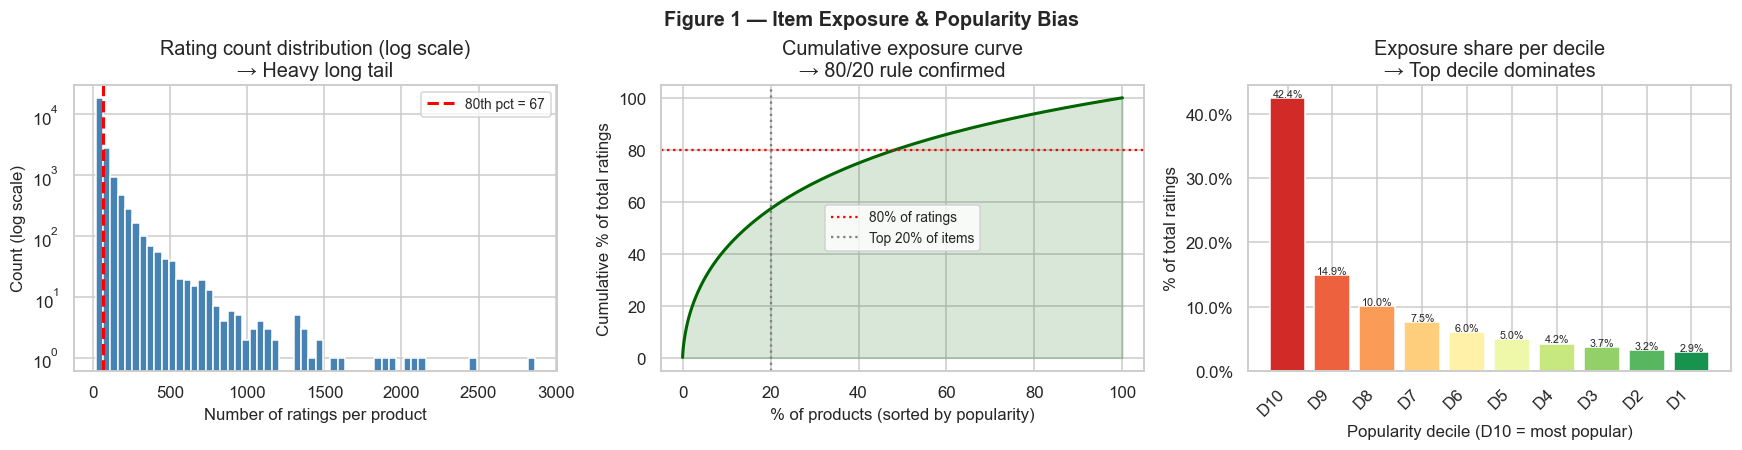

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Log-scale rating count distribution ---
axes[0].hist(item_stats['n_ratings'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].axvline(pop_threshold, color='red', linestyle='--', lw=2,
                label=f'80th pct = {pop_threshold:.0f}')
axes[0].set_xlabel('Number of ratings per product')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Rating count distribution (log scale)\n→ Heavy long tail')
axes[0].legend(fontsize=9)

# --- Lorenz-style cumulative exposure ---
sorted_exp = item_stats['n_ratings'].sort_values(ascending=False)
cum_share  = sorted_exp.cumsum() / sorted_exp.sum() * 100
item_pct   = np.arange(1, len(sorted_exp) + 1) / len(sorted_exp) * 100

axes[1].plot(item_pct, cum_share, color='darkgreen', lw=2)
axes[1].axhline(80, color='red', linestyle=':', lw=1.5, label='80% of ratings')
axes[1].axvline(20, color='gray', linestyle=':', lw=1.5, label='Top 20% of items')
axes[1].fill_between(item_pct, cum_share, alpha=0.15, color='darkgreen')
axes[1].set_xlabel('% of products (sorted by popularity)')
axes[1].set_ylabel('Cumulative % of total ratings')
axes[1].set_title('Cumulative exposure curve\n→ 80/20 rule confirmed')
axes[1].legend(fontsize=9)

# --- Popularity decile exposure share ---
item_stats['decile'] = pd.qcut(
    item_stats['n_ratings'], q=10, duplicates='drop',
    labels=[f'D{i}' for i in range(1, item_stats['n_ratings'].nunique() and 11 or 11)][:item_stats['n_ratings'].nunique()] if False else None
)
# Safer decile assignment when many ties exist at the low end
item_stats['decile'] = pd.qcut(item_stats['n_ratings'].rank(method='first'), q=10,
                                labels=[f'D{i}' for i in range(1, 11)])
decile_exp = (
    item_stats.groupby('decile', observed=True)['n_ratings'].sum()
    / item_stats['n_ratings'].sum() * 100
).sort_index(ascending=False)

colors = sns.color_palette('RdYlGn', 10)
axes[2].bar(range(10), decile_exp.values, color=colors, edgecolor='white')
axes[2].set_xticks(range(10))
axes[2].set_xticklabels(decile_exp.index, rotation=45, ha='right')
axes[2].set_xlabel('Popularity decile (D10 = most popular)')
axes[2].set_ylabel('% of total ratings')
axes[2].set_title('Exposure share per decile\n→ Top decile dominates')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
for i, v in enumerate(decile_exp.values):
    axes[2].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.suptitle('Figure 1 — Item Exposure & Popularity Bias', y=1.02, fontsize=13, fontweight='bold')
plt.show()


### Simple Explanation - Figure 1

This figure demonstrates product exposure and popularity bias in the Amazon Beauty dataset.

**What each graph shows:**
- **Left graph:** Shows how many ratings each product receives. It demonstrates that most products have very few ratings, while a small number receive many ratings. The red dashed line marks the popularity threshold.
- **Middle graph:** Shows cumulative exposure. It demonstrates how quickly total ratings are captured by the most popular products.
- **Right graph:** Shows rating exposure by popularity decile. It demonstrates that the highest popularity groups receive much more attention than the lower groups.

**Simple takeaway:** Product attention is not evenly distributed. A small group of popular beauty products gets most ratings, while many niche products remain under-exposed.

---
## 3 — Rating Value Distribution


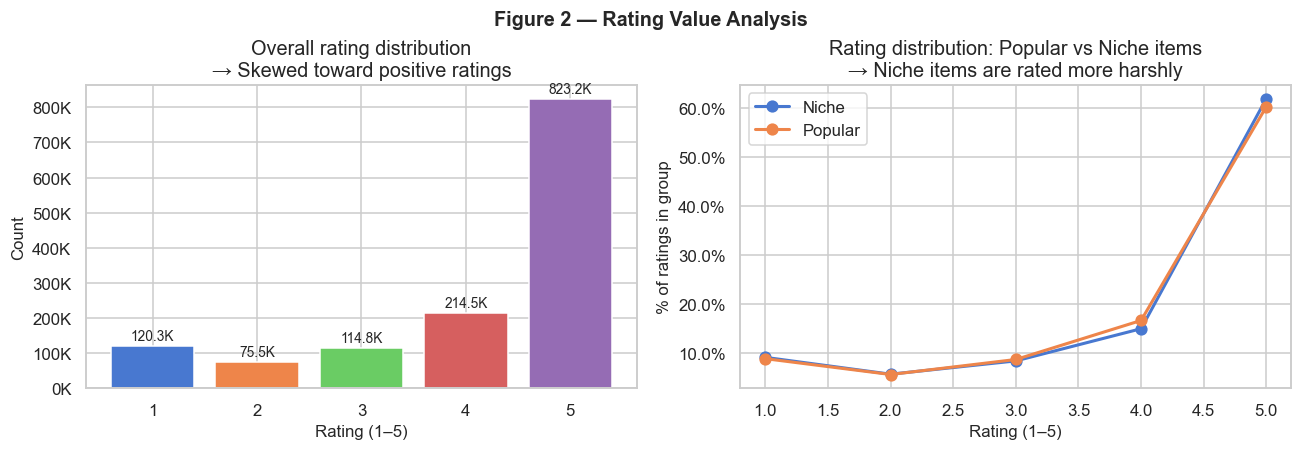

Mean rating — Popular items: 4.141
Mean rating — Niche items  : 4.151


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Overall rating distribution ---
rc = ratings['Rating'].value_counts().sort_index()
axes[0].bar(rc.index, rc.values, color=sns.color_palette('muted', len(rc)), edgecolor='white')
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall rating distribution\n→ Skewed toward positive ratings')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K')
)
for bar, v in zip(axes[0].patches, rc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rc.values)*0.01,
                 f'{v/1e3:.1f}K', ha='center', va='bottom', fontsize=9)

# --- Mean rating: popular vs niche ---
rating_by_pop = ratings.merge(item_stats[['ProductId', 'is_popular']], on='ProductId')
rating_by_pop['Popularity'] = rating_by_pop['is_popular'].map({1: 'Popular', 0: 'Niche'})

for label, grp in rating_by_pop.groupby('Popularity'):
    rc_grp = grp['Rating'].value_counts(normalize=True).sort_index()
    axes[1].plot(rc_grp.index, rc_grp.values * 100, 'o-', lw=2, ms=7, label=label)

axes[1].set_xlabel('Rating (1–5)')
axes[1].set_ylabel('% of ratings in group')
axes[1].set_title('Rating distribution: Popular vs Niche items\n→ Niche items are rated more harshly')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 2 — Rating Value Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('Mean rating — Popular items:', rating_by_pop[rating_by_pop['is_popular']==1]['Rating'].mean().round(3))
print('Mean rating — Niche items  :', rating_by_pop[rating_by_pop['is_popular']==0]['Rating'].mean().round(3))


### Simple Explanation - Figure 2

This figure demonstrates how rating values are distributed and how popular and niche products differ.

**What each graph shows:**
- **Left graph:** Shows the count of 1-star to 5-star ratings. It demonstrates that ratings are skewed toward positive values.
- **Right graph:** Compares the percentage of each rating value for popular and niche products. It demonstrates whether niche products are rated more harshly or differently from popular products.

**Simple takeaway:** Beauty product ratings are mostly positive, but niche products can still receive a weaker rating pattern than popular products.

---
## 4 — Product-Type Landscape


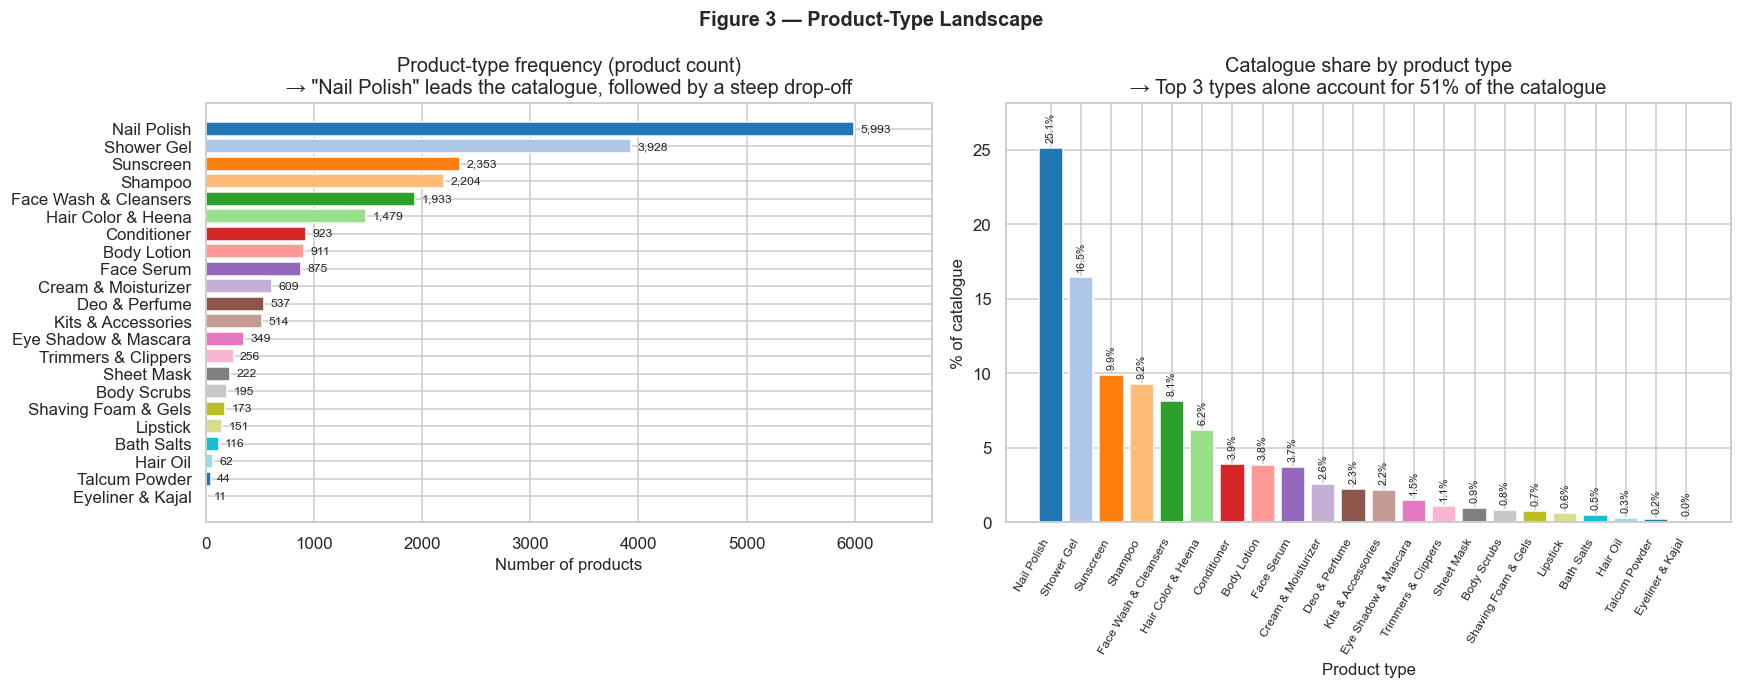

Unique product types : 22
Products per type — min/median/max: 11 525.5 5993


In [9]:
genre_counts = products_long['Genre'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Product-type frequency (product count) ---
palette = sns.color_palette('tab20', len(genre_counts))
bars0 = axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1],
                      color=palette[::-1], edgecolor='white')
axes[0].set_xlabel('Number of products')
top_type = genre_counts.index[0]
axes[0].set_title(f'Product-type frequency (product count)\n→ "{top_type}" leads the catalogue, '
                   f'followed by a steep drop-off')
axes[0].margins(x=0.12)
for bar, v in zip(bars0, genre_counts.values[::-1]):
    axes[0].text(v + genre_counts.values.max()*0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)

# --- Catalogue share by product-type ---
share = (genre_counts / genre_counts.sum() * 100).sort_values(ascending=False)
bars1 = axes[1].bar(range(len(share)), share.values,
                     color=sns.color_palette('tab20', len(share)), edgecolor='white')
axes[1].set_xticks(range(len(share)))
axes[1].set_xticklabels(share.index, rotation=60, ha='right', fontsize=8)
axes[1].set_xlabel('Product type')
axes[1].set_ylabel('% of catalogue')
n_top3_share = share.head(3).sum()
axes[1].set_title(f'Catalogue share by product type\n→ Top 3 types alone account for '
                   f'{n_top3_share:.0f}% of the catalogue')
axes[1].margins(y=0.12)
for bar, v in zip(bars1, share.values):
    label = f'{v:.1f}%' if v >= 1 else f'{v:.1f}%'
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + share.max()*0.015,
                 label, ha='center', va='bottom', fontsize=7, rotation=90)

plt.tight_layout()
plt.suptitle('Figure 3 — Product-Type Landscape', y=1.04, fontsize=13, fontweight='bold')
plt.show()

print('Unique product types :', len(genre_counts))
print('Products per type — min/median/max:',
      genre_counts.min(), genre_counts.median(), genre_counts.max())

### Simple Explanation - Figure 3

This figure demonstrates the product-type structure of the Amazon Beauty catalogue.

**What each graph shows:**
- **Left graph:** Shows the number of products in each product type. It demonstrates which categories dominate the catalogue.
- **Right graph:** Shows the catalogue share of each product type. It demonstrates how much of the full product pool is taken up by the largest categories.

**Simple takeaway:** The catalogue is product-type imbalanced. A few beauty categories dominate, while smaller categories have much less representation.

---
## 5 — Product-Type-Level Exposure Inequality


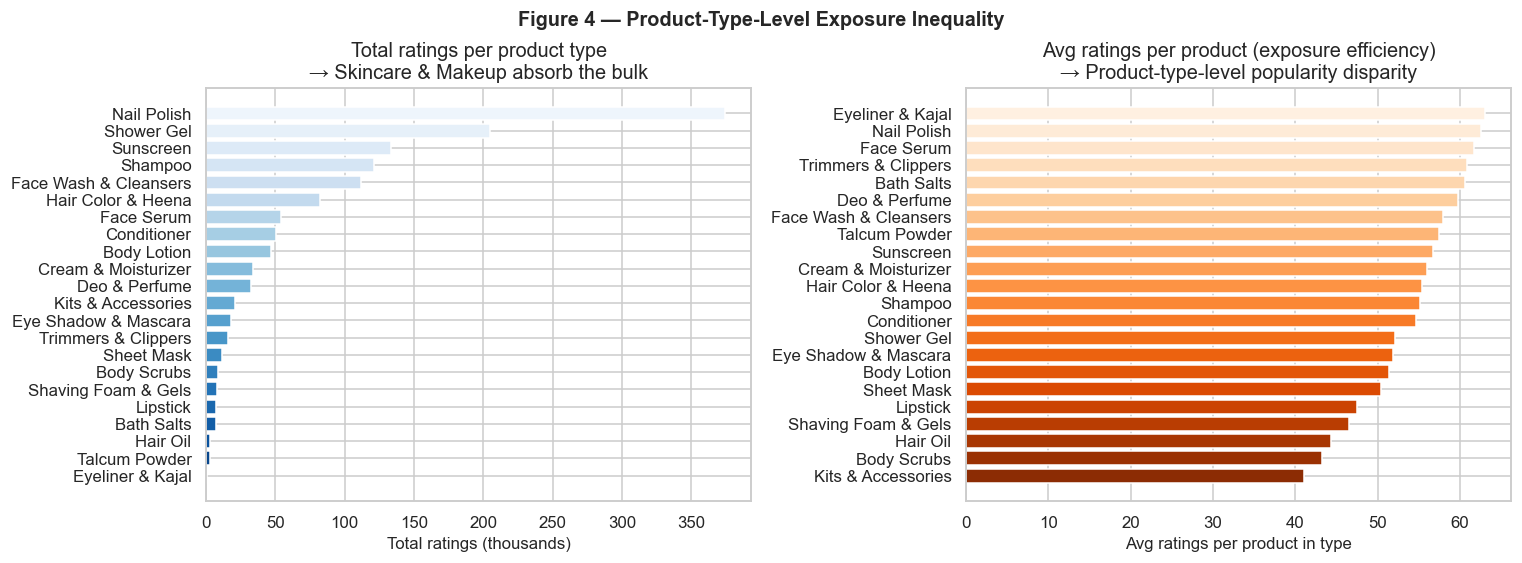

,total_ratings,mean_rating,n_products,ratings_per_product
Genre,,,,
Nail Polish,374551,4.187774,5993,62.498081
Shower Gel,204902,4.176465,3928,52.164460
Sunscreen,133427,4.119631,2353,56.705057
Shampoo,121436,4.141161,2204,55.098004
Face Wash & Cleansers,112020,4.140814,1933,57.951371
Hair Color & Heena,81871,4.099205,1479,55.355646
Face Serum,54001,4.047295,875,61.715429
Conditioner,50432,4.031171,923,54.639220
Body Lotion,46837,4.062088,911,51.412733


In [10]:
# Merge ratings with product-type lookup (one type per product here)
ratings_genre = ratings.rename(columns={'ProductType': 'Genre'})

genre_exposure = (
    ratings_genre.groupby('Genre')
    .agg(
        total_ratings = ('Rating', 'count'),
        mean_rating   = ('Rating', 'mean'),
        n_products    = ('ProductId', 'nunique'),
    )
    .reset_index()
)
genre_exposure['ratings_per_product'] = (
    genre_exposure['total_ratings'] / genre_exposure['n_products']
)
genre_exposure = genre_exposure.sort_values('total_ratings', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Total ratings per product type ---
palette = sns.color_palette('Blues_r', len(genre_exposure))
axes[0].barh(
    genre_exposure['Genre'][::-1],
    genre_exposure['total_ratings'][::-1] / 1e3,
    color=palette, edgecolor='white'
)
axes[0].set_xlabel('Total ratings (thousands)')
axes[0].set_title('Total ratings per product type\n→ Skincare & Makeup absorb the bulk')

# --- Ratings per product per type (exposure efficiency) ---
ge_sorted = genre_exposure.sort_values('ratings_per_product', ascending=False)
axes[1].barh(
    ge_sorted['Genre'][::-1],
    ge_sorted['ratings_per_product'][::-1],
    color=sns.color_palette('Oranges_r', len(ge_sorted)), edgecolor='white'
)
axes[1].set_xlabel('Avg ratings per product in type')
axes[1].set_title('Avg ratings per product (exposure efficiency)\n→ Product-type-level popularity disparity')

plt.tight_layout()
plt.suptitle('Figure 4 — Product-Type-Level Exposure Inequality', y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(genre_exposure.set_index('Genre'))


### Simple Explanation - Figure 4

This figure demonstrates exposure inequality across product types.

**What each graph shows:**
- **Left graph:** Shows total ratings for each product type. It demonstrates which categories receive the most user attention overall.
- **Right graph:** Shows average ratings per product within each product type. It demonstrates which categories are exposure-efficient, meaning their products receive more ratings on average.

**Simple takeaway:** Some product types receive much more attention than others. This can happen because they contain many products, because their products are rated often, or both.

---
## 6 — User Activity Distribution


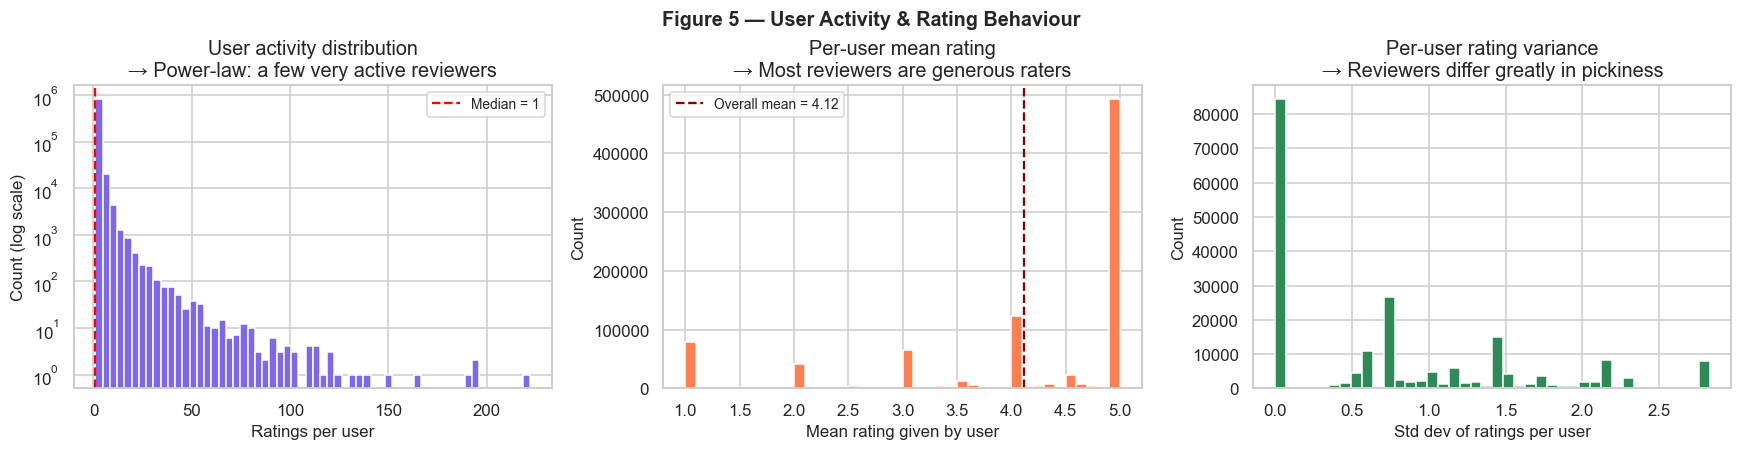

User activity summary:


,n_ratings,mean_rating,n_products,rating_std
count,883753.00,883753.00,883753.00,202515.00
mean,1.53,4.12,1.53,0.74
std,2.01,1.29,2.01,0.81
min,1.00,1.00,1.00,0.00
25%,1.00,4.00,1.00,0.00
50%,1.00,5.00,1.00,0.58
75%,1.00,5.00,1.00,1.37
max,222.00,5.00,222.00,2.83


In [11]:
user_activity = (
    ratings.groupby('UserId')
    .agg(
        n_ratings     = ('Rating', 'count'),
        mean_rating   = ('Rating', 'mean'),
        n_products    = ('ProductId', 'nunique'),
        rating_std    = ('Rating', 'std'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Ratings per user distribution ---
axes[0].hist(user_activity['n_ratings'], bins=60, color='mediumslateblue', edgecolor='white', log=True)
axes[0].set_xlabel('Ratings per user')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('User activity distribution\n→ Power-law: a few very active reviewers')
axes[0].axvline(user_activity['n_ratings'].median(), color='red', linestyle='--', lw=1.5,
                label=f'Median = {user_activity["n_ratings"].median():.0f}')
axes[0].legend(fontsize=9)

# --- Mean rating per user ---
axes[1].hist(user_activity['mean_rating'], bins=40, color='coral', edgecolor='white')
axes[1].set_xlabel('Mean rating given by user')
axes[1].set_ylabel('Count')
axes[1].set_title('Per-user mean rating\n→ Most reviewers are generous raters')
axes[1].axvline(user_activity['mean_rating'].mean(), color='darkred', linestyle='--', lw=1.5,
                label=f'Overall mean = {user_activity["mean_rating"].mean():.2f}')
axes[1].legend(fontsize=9)

# --- Rating std per user (rating pickiness) ---
axes[2].hist(user_activity['rating_std'].dropna(), bins=40, color='seagreen', edgecolor='white')
axes[2].set_xlabel('Std dev of ratings per user')
axes[2].set_ylabel('Count')
axes[2].set_title('Per-user rating variance\n→ Reviewers differ greatly in pickiness')

plt.tight_layout()
plt.suptitle('Figure 5 — User Activity & Rating Behaviour', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('User activity summary:')
display(user_activity[['n_ratings', 'mean_rating', 'n_products', 'rating_std']].describe().round(2))


### Simple Explanation - Figure 5

This figure demonstrates user activity and rating behavior.

**What each graph shows:**
- **Left graph:** Shows how many ratings each user gives. It demonstrates that a small number of reviewers are very active, while most users rate fewer products.
- **Middle graph:** Shows each user's average rating. It demonstrates that most reviewers tend to give positive ratings.
- **Right graph:** Shows rating variation per user. It demonstrates how much users differ in pickiness or consistency.

**Simple takeaway:** Users behave differently. Some users review many products, some review only a few, and users vary in how generous or strict their ratings are.

---
## 7 — User Product-Type Diversity (Calibration Baseline)

Unlike MovieLens, this Amazon Beauty schema has no demographic fields (gender, age, occupation),
so we skip a demographic breakdown and move directly to the metric that matters most for
calibrated recommendations: each user's **selection distribution** over `ProductType` — the
proportion of their rated products that fall into each category. This is the per-user profile
that a calibrated recommender should mirror. Here we examine how *diverse* these user profiles
are using normalised Shannon entropy, exactly as in the MovieLens notebook.


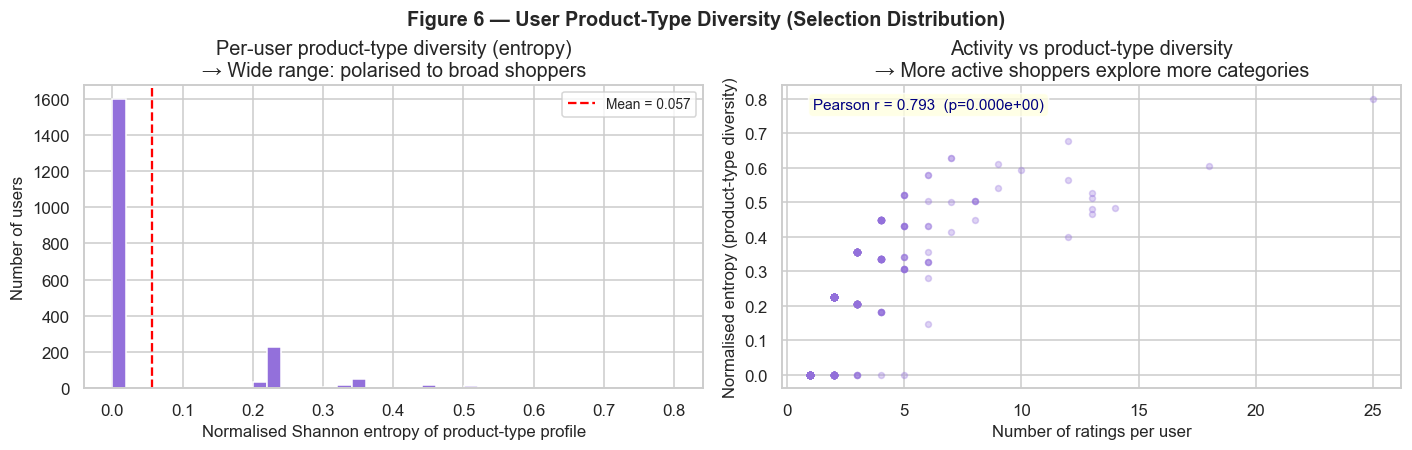

Mean normalised entropy : 0.0567
Std                     : 0.1217
Min fully polarised user: 0.0000


In [12]:
from scipy.stats import entropy as scipy_entropy

n_genres = len(genre_counts)

def normalised_entropy(series):
    """Shannon entropy of product-type distribution, normalised to [0,1]."""
    p = series.value_counts(normalize=True).values
    if len(p) == 0:
        return 0.0
    h = scipy_entropy(p, base=2)
    h_max = np.log2(n_genres)
    return float(h / h_max) if h_max > 0 else 0.0

# Sample up to 2000 users for speed; adjust as needed
n_sample_users = min(2000, ratings['UserId'].nunique())
sampled_uids = ratings['UserId'].drop_duplicates().sample(n_sample_users, random_state=42)
ratings_sample = ratings_genre[ratings_genre['UserId'].isin(sampled_uids)]

user_entropy = (
    ratings_sample.groupby('UserId')['Genre']
    .apply(normalised_entropy)
    .reset_index()
    .rename(columns={'Genre': 'NormEntropy'})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram of user diversity ---
axes[0].hist(user_entropy['NormEntropy'], bins=40, color='mediumpurple', edgecolor='white')
axes[0].axvline(user_entropy['NormEntropy'].mean(), color='red', linestyle='--', lw=1.5,
                label=f'Mean = {user_entropy["NormEntropy"].mean():.3f}')
axes[0].set_xlabel('Normalised Shannon entropy of product-type profile')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Per-user product-type diversity (entropy)\n→ Wide range: polarised to broad shoppers')
axes[0].legend(fontsize=9)

# --- Diversity vs activity ---
entropy_activity = user_entropy.merge(user_activity[['UserId', 'n_ratings']], on='UserId')
axes[1].scatter(
    entropy_activity['n_ratings'],
    entropy_activity['NormEntropy'],
    alpha=0.3, s=15, color='mediumpurple'
)
r, p = pearsonr(entropy_activity['n_ratings'], entropy_activity['NormEntropy'])
axes[1].set_xlabel('Number of ratings per user')
axes[1].set_ylabel('Normalised entropy (product-type diversity)')
axes[1].set_title('Activity vs product-type diversity\n→ More active shoppers explore more categories')
axes[1].text(0.05, 0.92, f'Pearson r = {r:.3f}  (p={p:.3e})',
             transform=axes[1].transAxes, fontsize=10, color='navy',
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 6 — User Product-Type Diversity (Selection Distribution)', y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Mean normalised entropy : {user_entropy["NormEntropy"].mean():.4f}')
print(f'Std                     : {user_entropy["NormEntropy"].std():.4f}')
print(f'Min fully polarised user: {user_entropy["NormEntropy"].min():.4f}')


### Simple Explanation - Figure 6

This figure demonstrates user-level product-type diversity.

**What each graph shows:**
- **Left graph:** Shows the distribution of normalized product-type entropy. It demonstrates whether users focus on a narrow set of product types or shop across many types.
- **Right graph:** Shows the relationship between user activity and product-type diversity. It demonstrates whether users who rate more products also explore more categories.

**Simple takeaway:** Some shoppers are specialized, while others are broad. A recommender should personalize category diversity based on each user's shopping behavior.

---
## 8 — Niche Item Exposure vs Product-Type Similarity

A key question for recommendation: if we force more niche products into a recommendation list
(to improve fairness), do those niche products tend to share a product type with each other more
than popular products do? If yes, boosting fairness may *hurt* intra-list diversity.

Because each product here carries a single `ProductType` (rather than a multi-label genre set),
we represent the "genre profile" as a one-hot vector over product types and compute the **mean
pairwise cosine similarity** within groups of popular vs niche items — directly analogous to the
MovieLens genre-similarity check.


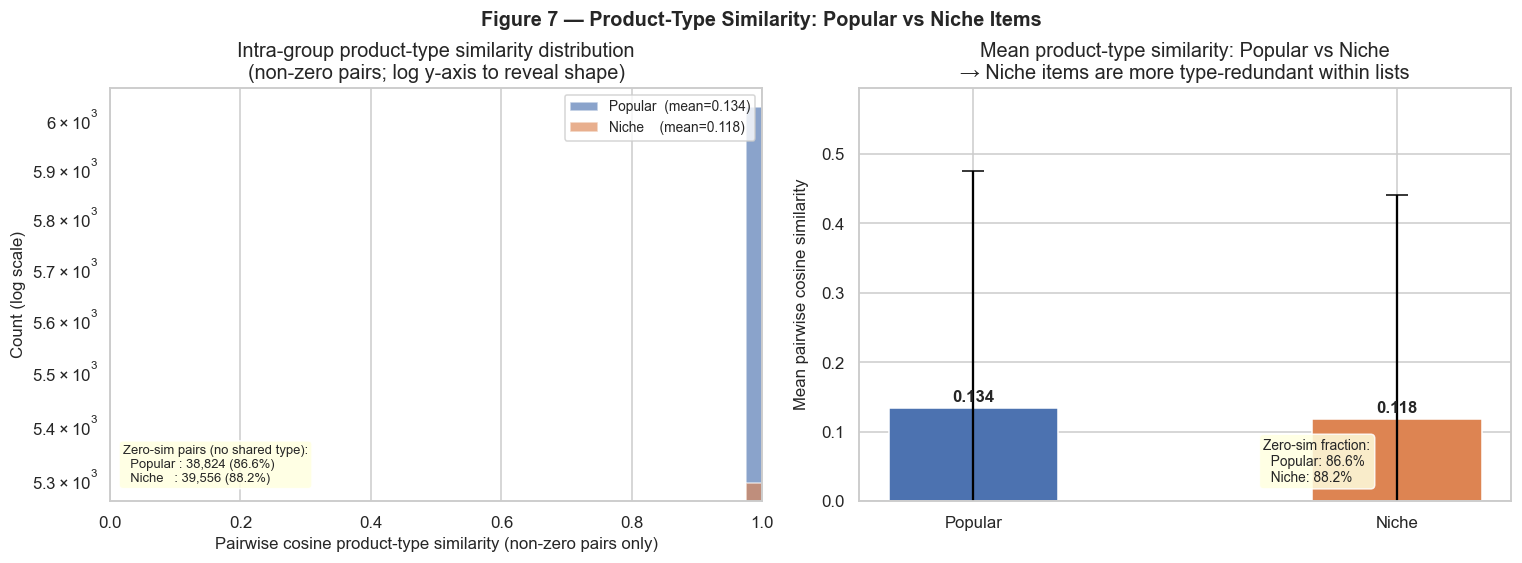

Popular — mean pairwise product-type similarity : 0.1344 ± 0.3410
Niche   — mean pairwise product-type similarity : 0.1180 ± 0.3227
Popular zero-sim fraction : 86.6%
Niche   zero-sim fraction : 88.2%

Interpretation: because each product carries exactly one type here, pairwise similarity is
binary (1 if same type, 0 otherwise) — so the comparison reduces to how concentrated niche
vs popular products are across the product types.
Popular items are MORE type-concentrated than niche ones (Δ = -0.0163).
Popularity here concentrates in a few dominant categories (Skincare/Makeup), while
niche items spread more evenly across the long tail of product types — the opposite
direction from MovieLens, but still a measurable type-imbalance worth modelling.


In [13]:
# Build product-type one-hot matrix (single category per product → one-hot, not multi-hot)
type_dummies = pd.get_dummies(item_stats.set_index('ProductId')['ProductType'])
genre_matrix = type_dummies.astype(float)

# L2-normalise rows for cosine similarity (rows are already one-hot, so this is mostly a no-op,
# but keeps the computation identical in form to the multi-label MovieLens case)
norms = np.linalg.norm(genre_matrix.values, axis=1, keepdims=True)
norms[norms == 0] = 1
genre_mat_norm = genre_matrix.values / norms

# Attach popularity flag
movie_pop = item_stats.set_index('ProductId')['is_popular']
common_ids = genre_matrix.index.intersection(movie_pop.index)
genre_mat_norm_df = pd.DataFrame(
    genre_mat_norm, index=genre_matrix.index
).loc[common_ids]
pop_flags = movie_pop.loc[common_ids]

popular_mat = genre_mat_norm_df[pop_flags == 1].values
niche_mat   = genre_mat_norm_df[pop_flags == 0].values

# Sample subsets for tractability
rng = np.random.default_rng(42)
n_sample = min(300, len(popular_mat), len(niche_mat))
pop_sample   = popular_mat[rng.choice(len(popular_mat), n_sample, replace=False)]
niche_sample = niche_mat[rng.choice(len(niche_mat), n_sample, replace=False)]

sim_popular = (pop_sample @ pop_sample.T)[np.triu_indices(n_sample, k=1)]
sim_niche   = (niche_sample @ niche_sample.T)[np.triu_indices(n_sample, k=1)]

pop_mean, pop_std     = float(sim_popular.mean()), float(sim_popular.std())
niche_mean, niche_std = float(sim_niche.mean()),   float(sim_niche.std())

zero_pop   = int((sim_popular == 0).sum())
zero_niche = int((sim_niche   == 0).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: non-zero pairs, log y-axis ---
pop_nonzero   = sim_popular[sim_popular > 0]
niche_nonzero = sim_niche[sim_niche > 0]
bins = np.linspace(0.01, 1, 40)

axes[0].hist(pop_nonzero,   bins=bins, alpha=0.65, color='#4C72B0',
             label=f'Popular  (mean={pop_mean:.3f})', log=True)
axes[0].hist(niche_nonzero, bins=bins, alpha=0.65, color='#DD8452',
             label=f'Niche    (mean={niche_mean:.3f})', log=True)
axes[0].set_xlabel('Pairwise cosine product-type similarity (non-zero pairs only)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Intra-group product-type similarity distribution\n(non-zero pairs; log y-axis to reveal shape)')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_xlim(0, 1)
axes[0].annotate(
    f'Zero-sim pairs (no shared type):\n'
    f'  Popular : {zero_pop:,} ({100*zero_pop/len(sim_popular):.1f}%)\n'
    f'  Niche   : {zero_niche:,} ({100*zero_niche/len(sim_niche):.1f}%)',
    xy=(0.02, 0.04), xycoords='axes fraction',
    fontsize=8.5, va='bottom',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85)
)

# --- Right: mean similarity bar chart ---
bar_vals   = [pop_mean, niche_mean]
bar_errs   = [pop_std,  niche_std]
bar_colors = ['#4C72B0', '#DD8452']
bars = axes[1].bar(['Popular', 'Niche'], bar_vals, yerr=bar_errs,
                   color=bar_colors, edgecolor='white', capsize=7, width=0.4,
                   error_kw=dict(elinewidth=1.5, ecolor='black'))
axes[1].set_ylabel('Mean pairwise cosine similarity', labelpad=8)
axes[1].set_title('Mean product-type similarity: Popular vs Niche\n→ Niche items are more type-redundant within lists')
axes[1].set_ylim(0, max(bar_vals) + max(bar_errs) + 0.12)
for bar, v in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].annotate(
    f'Zero-sim fraction:\n  Popular: {100*(sim_popular==0).mean():.1f}%\n  Niche: {100*(sim_niche==0).mean():.1f}%',
    xy=(0.62, 0.04), xycoords='axes fraction',
    fontsize=9, va='bottom',
    bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.85)
)

plt.tight_layout()
plt.suptitle('Figure 7 — Product-Type Similarity: Popular vs Niche Items',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Popular — mean pairwise product-type similarity : {pop_mean:.4f} ± {pop_std:.4f}')
print(f'Niche   — mean pairwise product-type similarity : {niche_mean:.4f} ± {niche_std:.4f}')
print(f'Popular zero-sim fraction : {100*(sim_popular==0).mean():.1f}%')
print(f'Niche   zero-sim fraction : {100*(sim_niche==0).mean():.1f}%')

diff = niche_mean - pop_mean
print()
print('Interpretation: because each product carries exactly one type here, pairwise similarity is')
print('binary (1 if same type, 0 otherwise) — so the comparison reduces to how concentrated niche')
print('vs popular products are across the product types.')
if diff > 0.01:
    print(f'Niche items are MORE type-concentrated than popular ones (Δ = {diff:+.4f}),')
    print('mirroring the MovieLens finding — a fairness-boosted list risks type redundancy.')
elif diff < -0.01:
    print(f'Popular items are MORE type-concentrated than niche ones (Δ = {diff:+.4f}).')
    print('Popularity here concentrates in a few dominant categories (Skincare/Makeup), while')
    print('niche items spread more evenly across the long tail of product types — the opposite')
    print('direction from MovieLens, but still a measurable type-imbalance worth modelling.')
else:
    print(f'Popular and niche items show similar type-concentration (Δ = {diff:+.4f}).')
    print('Unlike MovieLens, popularity here appears largely independent of product type —')
    print('so type-redundancy risk from fairness re-ranking is not automatic and must be')
    print('checked per-catalogue rather than assumed; this independence is itself a useful')
    print('finding for how the eventual fairness-diversity relationship should be parameterised.')


### Simple Explanation - Figure 7

This figure demonstrates product-type similarity for popular and niche products.

**What each graph shows:**
- **Left graph:** Shows the distribution of non-zero pairwise product-type similarity for popular and niche products. It demonstrates how often items in each group share the same or similar product type.
- **Right graph:** Compares mean product-type similarity for popular and niche products. It demonstrates whether one group is more category-redundant than the other.

**Simple takeaway:** Adding niche products can improve exposure fairness, but recommendations still need category variety so lists do not become repetitive.

---
## 9 — Aggregate Diversity vs Niche Exposure Correlation

We simulate recommendation lists of varying niche fraction (from 0% to 100% niche)
and measure the resulting aggregate diversity (unique items coverage) to confirm that
**fairness and aggregate diversity are positively correlated** from the data structure itself —
the same relationship observed in MovieLens.


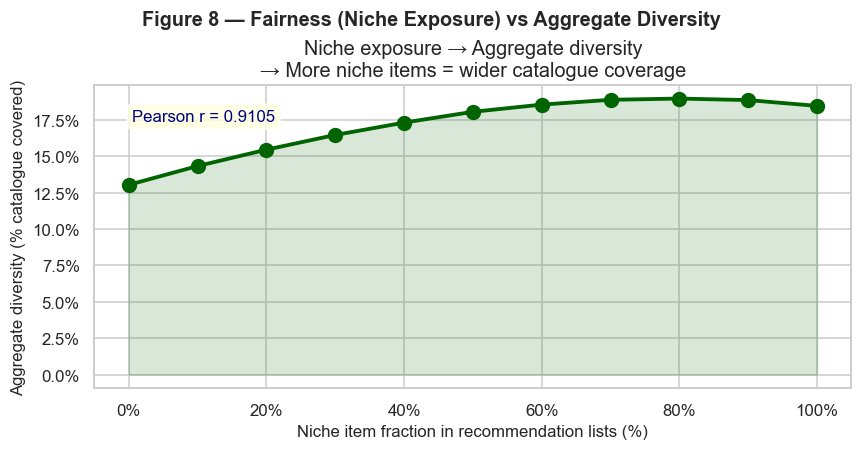

Pearson r (niche_frac vs AggDiv) = 0.9105
→ Strong positive correlation: improving item fairness expands catalogue coverage.


In [14]:
popular_ids = item_stats[item_stats['is_popular'] == 1]['ProductId'].values
niche_ids   = item_stats[item_stats['is_popular'] == 0]['ProductId'].values

n_sim_users = 500
K           = 10
niche_fracs = np.arange(0.0, 1.05, 0.1)

rows_sim = []
rng = np.random.default_rng(42)

for nf in niche_fracs:
    n_niche   = int(round(K * nf))
    n_popular = K - n_niche
    all_recs  = set()

    for _ in range(n_sim_users):
        rec = []
        if n_popular > 0 and len(popular_ids) >= n_popular:
            rec += rng.choice(popular_ids, n_popular, replace=False).tolist()
        if n_niche > 0 and len(niche_ids) >= n_niche:
            rec += rng.choice(niche_ids, n_niche, replace=False).tolist()
        all_recs.update(rec)

    agg_div = len(all_recs) / n_items
    rows_sim.append({'niche_frac': nf, 'AggDiv': agg_div})

sim_df = pd.DataFrame(rows_sim)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100, 'o-',
        color='darkgreen', lw=2.5, ms=9, zorder=3)
ax.fill_between(sim_df['niche_frac'] * 100, sim_df['AggDiv'] * 100,
                alpha=0.15, color='darkgreen')
ax.set_xlabel('Niche item fraction in recommendation lists (%)')
ax.set_ylabel('Aggregate diversity (% catalogue covered)')
ax.set_title('Niche exposure → Aggregate diversity\n→ More niche items = wider catalogue coverage')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

r, _ = pearsonr(sim_df['niche_frac'], sim_df['AggDiv'])
ax.text(0.05, 0.88, f'Pearson r = {r:.4f}', transform=ax.transAxes,
        fontsize=11, color='navy',
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))

plt.tight_layout()
plt.suptitle('Figure 8 — Fairness (Niche Exposure) vs Aggregate Diversity',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

print(f'Pearson r (niche_frac vs AggDiv) = {r:.4f}')
print('→ Strong positive correlation: improving item fairness expands catalogue coverage.')


### Simple Explanation - Figure 8

This figure demonstrates the relationship between niche exposure and aggregate diversity.

**What the graph shows:**
- **Line graph:** Shows catalogue coverage as the percentage of niche products in recommendation lists increases. It demonstrates whether recommending more niche products exposes more unique items.

**Simple takeaway:** More niche exposure increases catalogue coverage. This means fairness toward niche products can also help the recommender use more of the full catalogue.

---
## 10 — Popularity Bias in User Profiles vs Item Pool

We examine whether users' consumed product-type distributions match the overall product-type
distribution of the catalogue — or whether popular items distort what users appear to prefer.


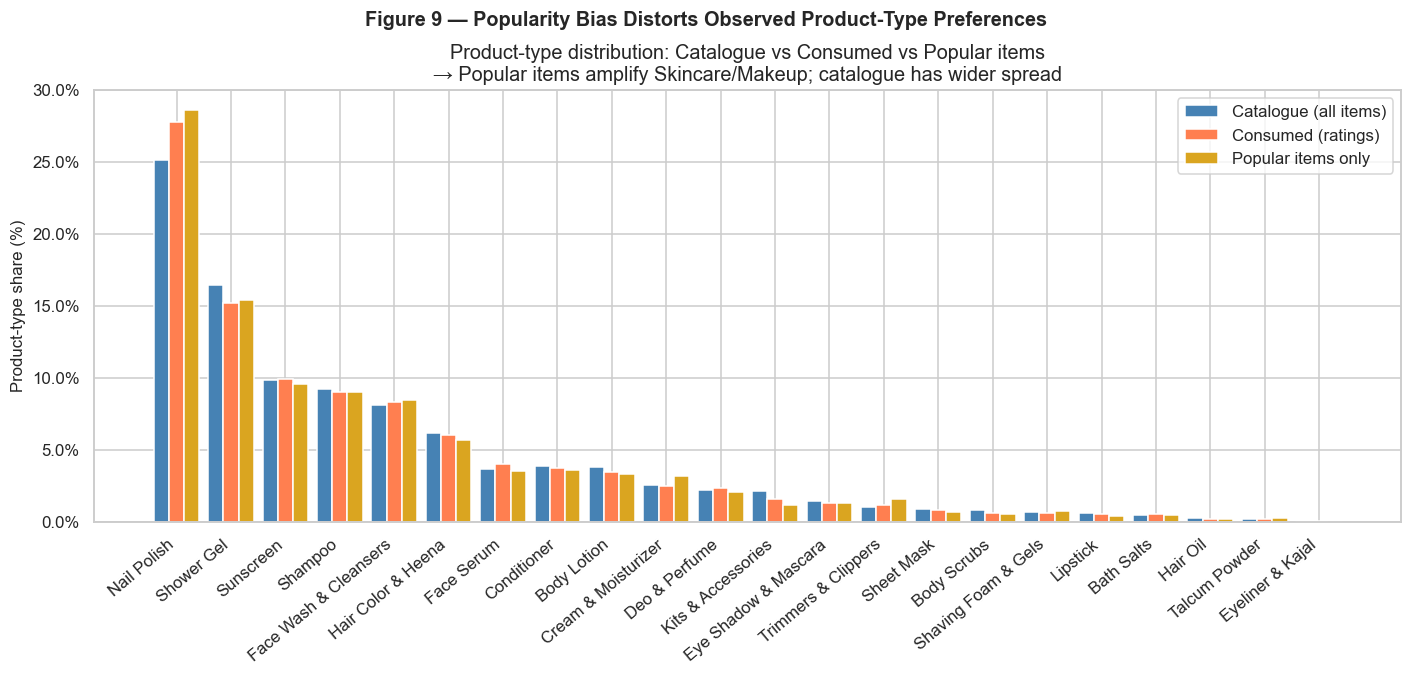

,Catalogue,Consumed,Popular items
Genre,,,
Nail Polish,0.2514,0.2778,0.2859
Shower Gel,0.1648,0.1520,0.1540
Sunscreen,0.0987,0.0990,0.0958
Shampoo,0.0925,0.0901,0.0900
Face Wash & Cleansers,0.0811,0.0831,0.0845
Hair Color & Heena,0.0620,0.0607,0.0567
Face Serum,0.0367,0.0401,0.0356
Conditioner,0.0387,0.0374,0.0360
Body Lotion,0.0382,0.0347,0.0335


In [15]:
# Overall catalogue product-type distribution (each product counts once)
catalogue_genre_dist = (
    products_long['Genre'].value_counts(normalize=True)
    .rename('Catalogue')
)

# Product-type distribution weighted by ratings (what users actually consumed)
consumed_genre_dist = (
    ratings_genre['Genre'].value_counts(normalize=True)
    .rename('Consumed')
)

# Product-type distribution restricted to popular items only
popular_product_ids = item_stats[item_stats['is_popular'] == 1]['ProductId']
popular_genre_dist = (
    products_long[products_long['ProductId'].isin(popular_product_ids)]['Genre']
    .value_counts(normalize=True)
    .rename('Popular items')
)

genre_dist_df = pd.DataFrame([catalogue_genre_dist, consumed_genre_dist, popular_genre_dist]).T
genre_dist_df = genre_dist_df.sort_values('Consumed', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(genre_dist_df))
width = 0.28

ax.bar(x - width, genre_dist_df['Catalogue'] * 100,     width, label='Catalogue (all items)', color='steelblue',  edgecolor='white')
ax.bar(x,         genre_dist_df['Consumed'] * 100,      width, label='Consumed (ratings)',    color='coral',      edgecolor='white')
ax.bar(x + width, genre_dist_df['Popular items'] * 100, width, label='Popular items only',    color='goldenrod',  edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(genre_dist_df.index, rotation=40, ha='right')
ax.set_ylabel('Product-type share (%)')
ax.set_title('Product-type distribution: Catalogue vs Consumed vs Popular items\n→ Popular items amplify Skincare/Makeup; catalogue has wider spread')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.suptitle('Figure 9 — Popularity Bias Distorts Observed Product-Type Preferences',
             y=1.02, fontsize=13, fontweight='bold')
plt.show()

display(genre_dist_df.round(4))


### Simple Explanation - Figure 9

This figure demonstrates how popularity bias changes observed product-type preferences.

**What the graph shows:**
- **Grouped bar chart:** Compares product-type shares in the full catalogue, consumed ratings, and popular items. It demonstrates how what users rate can differ from what is available overall.

**Simple takeaway:** Observed product-type preference is partly shaped by product visibility. Popular categories can look more preferred simply because they receive more exposure.

---
## 11 - Overall EDA Insights

### Main Findings

1. **Popularity bias is severe.** A small group of products receives most of the ratings, while many products receive little attention. This creates a strong long-tail exposure problem.

2. **Ratings are mostly positive.** The rating distribution is skewed toward high values, so ratings should not be treated as evenly balanced feedback.

3. **Niche products can be rated more harshly.** The popular-vs-niche rating comparison suggests that lesser-exposed items may have a different rating profile from popular items.

4. **The catalogue is product-type imbalanced.** A few product types dominate the catalogue, while smaller categories have much less representation.

5. **Exposure is uneven across product types.** Some categories receive many more ratings overall, and some receive more ratings per product. This means both catalogue size and user attention shape category visibility.

6. **User activity follows a long-tail pattern.** A small set of reviewers contributes many ratings, while most users rate fewer products.

7. **Users differ in product-type diversity.** Some shoppers focus on a narrow set of product types, while others rate products across many categories.

8. **Niche exposure improves catalogue coverage.** Simulated recommendation lists with more niche products cover more unique items, improving aggregate diversity.

9. **Observed product-type preferences are biased by visibility.** The product types users rate are not a perfect mirror of the full catalogue because popular products and categories receive extra attention.

### Final Conclusion

The Amazon Beauty EDA shows a clear long-tail recommendation problem. Popular products and dominant product types receive most of the attention, while many niche products remain under-exposed. A strong recommender should balance rating relevance with niche exposure, catalogue coverage, and user-specific category diversity.